In [23]:
!pip install kaggle

In [24]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [25]:
!mkdir -p data/raw
%cd data/raw

!kaggle datasets download -d eswarchandt/phishing-website-detector
!kaggle datasets download -d uciml/sms-spam-collection-dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud

/content/data/raw
Dataset URL: https://www.kaggle.com/datasets/eswarchandt/phishing-website-detector
License(s): unknown
phishing-website-detector.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
sms-spam-collection-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


In [26]:
!unzip "*.zip"

Archive:  creditcardfraud.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: creditcard.csv          

Archive:  sms-spam-collection-dataset.zip
replace spam.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: spam.csv                

Archive:  phishing-website-detector.zip
replace phishing.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: phishing.csv            
replace phishing.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: phishing.txt            

3 archives were successfully processed.


In [27]:
%cd /content

/content


In [28]:
data_path = "data/raw"

In [29]:
import pandas as pd
import os

data_path = "data/raw"
datasets = {}

for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)

        try:
            df = pd.read_csv(file_path, encoding='utf-8')
        except UnicodeDecodeError:
            try:
                df = pd.read_csv(file_path, encoding='latin1')
            except:
                df = pd.read_csv(file_path, encoding='ISO-8859-1')

        datasets[file] = df
        print(f"{file} -> {df.shape}")

spam.csv -> (5572, 5)
phishing.csv -> (11054, 32)
creditcard.csv -> (284807, 31)


In [30]:
!ls /content/data/raw

creditcard.csv	     phishing.csv  phishing-website-detector.zip    spam.csv
creditcardfraud.zip  phishing.txt  sms-spam-collection-dataset.zip


In [31]:
!unzip "/content/data/raw/*.zip" -d /content/data/raw

Archive:  /content/data/raw/creditcardfraud.zip
replace /content/data/raw/creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/data/raw/creditcard.csv  y


Archive:  /content/data/raw/sms-spam-collection-dataset.zip
replace /content/data/raw/spam.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: /content/data/raw/spam.csv  

Archive:  /content/data/raw/phishing-website-detector.zip
replace /content/data/raw/phishing.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/data/raw/phishing.csv  
replace /content/data/raw/phishing.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/data/raw/phishing.txt  

3 archives were successfully processed.


In [32]:
!pwd

/content


In [33]:
!ls /content

data  day2_eda.ipynb  drive  kaggle.json  sample_data


In [34]:
!rm *.zip

rm: cannot remove '*.zip': No such file or directory


In [35]:
!ls /content/data/raw

creditcard.csv	     phishing.csv  phishing-website-detector.zip    spam.csv
creditcardfraud.zip  phishing.txt  sms-spam-collection-dataset.zip


In [36]:
data_path = "day2_eda.ipynb/raw"

In [37]:
import os
print(os.listdir(data_path))

[]


In [38]:
!mkdir -p /content/data/raw
!mv day2_eda.ipynb/raw/* /content/data/raw/

mv: cannot stat 'day2_eda.ipynb/raw/*': No such file or directory


In [39]:
data_path = "data/raw"

In [41]:
from google.colab import files
files.download('day2_eda.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
!git clone https://github.com/Perera1325/adaptive-fraud-ml-pipeline.git

Cloning into 'adaptive-fraud-ml-pipeline'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 33 (delta 7), reused 30 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 5.23 KiB | 2.61 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [43]:
!cp day2_eda.ipynb adaptive-fraud-ml-pipeline/notebooks/

cp: -r not specified; omitting directory 'day2_eda.ipynb'


In [44]:
%cd adaptive-fraud-ml-pipeline

/content/adaptive-fraud-ml-pipeline


In [45]:
!git config --global user.email "bamunuge2002@gmail.com"
!git config --global user.name "Perera1325"

In [46]:
!git add notebooks/day2_eda.ipynb
!git commit -m "notebook: add day 2 EDA from colab"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [47]:
!git push

fatal: could not read Username for 'https://github.com': No such device or address


## Day 3 - Unified Fraud Dataset Construction

In [49]:
print(datasets.keys())

dict_keys(['spam.csv', 'phishing.csv', 'creditcard.csv'])


In [50]:
spam_df = datasets['spam.csv']

In [51]:
phishing_df = datasets['phishing.csv']
cc_df = datasets['creditcard.csv']

In [53]:
spam_df.head()
spam_df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [54]:
spam_df = spam_df.rename(columns={
    spam_df.columns[0]: 'label',
    spam_df.columns[1]: 'text'
})

# convert label to numeric
spam_df['label'] = spam_df['label'].map({'ham': 0, 'spam': 1})

spam_df['type'] = 'spam'
spam_df['amount'] = 0

In [55]:
phishing_df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [56]:
phishing_df['type'] = 'phishing'

# no real text → create placeholder
phishing_df['text'] = 'phishing_url'

# label is usually last column
phishing_df['label'] = phishing_df.iloc[:, -1]

phishing_df['amount'] = 0

In [57]:
cc_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [58]:
cc_df['type'] = 'transaction'

cc_df['text'] = 'transaction_data'

cc_df['amount'] = cc_df['Amount']

cc_df['label'] = cc_df['Class']

In [59]:
common_cols = ['type', 'text', 'amount', 'label']

spam_final = spam_df[common_cols]
phishing_final = phishing_df[common_cols]
cc_final = cc_df[common_cols]

In [60]:
import pandas as pd

unified_df = pd.concat([
    spam_final,
    phishing_final,
    cc_final
], ignore_index=True)

print(unified_df.shape)
unified_df.head()

(301433, 4)


,type,text,amount,label
0,spam,"Go until jurong point, crazy.. Available only ...",0.0,0
1,spam,Ok lar... Joking wif u oni...,0.0,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0.0,1
3,spam,U dun say so early hor... U c already then say...,0.0,0
4,spam,"Nah I don't think he goes to usf, he lives aro...",0.0,0


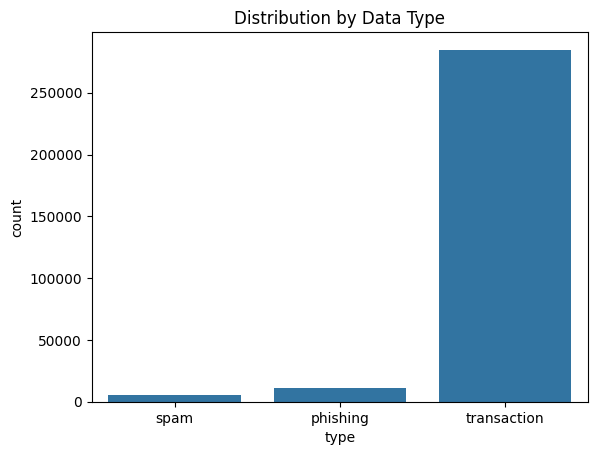

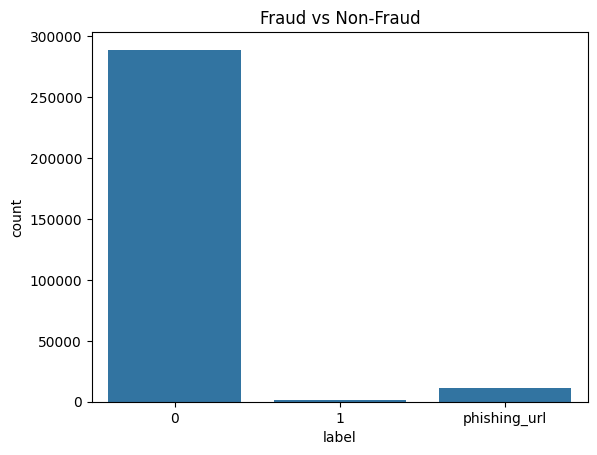

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=unified_df)
plt.title("Distribution by Data Type")
plt.show()

sns.countplot(x='label', data=unified_df)
plt.title("Fraud vs Non-Fraud")
plt.show()

In [62]:
!mkdir -p data/processed
unified_df.to_csv("data/processed/unified_fraud.csv", index=False)

DAY 4 — Data Preparation + Feature Engineering

In [63]:
import pandas as pd

df = pd.read_csv("data/processed/unified_fraud.csv")
df.head()

/tmp/ipykernel_152/2781290907.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/processed/unified_fraud.csv")


,type,text,amount,label
0,spam,"Go until jurong point, crazy.. Available only ...",0.0,0
1,spam,Ok lar... Joking wif u oni...,0.0,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0.0,1
3,spam,U dun say so early hor... U c already then say...,0.0,0
4,spam,"Nah I don't think he goes to usf, he lives aro...",0.0,0


In [64]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301433 entries, 0 to 301432
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   type    301433 non-null  object 
 1   text    301433 non-null  object 
 2   amount  301433 non-null  float64
 3   label   301433 non-null  object 
dtypes: float64(1), object(3)
memory usage: 9.2+ MB


,count
label,
0,170111
0,119029
phishing_url,11054
1,989
1,250


In [65]:
!pip install imbalanced-learn

In [67]:
print(df['label'].unique())

['0' '1' 'phishing_url' 0 1]


In [69]:
df['label'] = df['label'].apply(
    lambda x: 1 if str(x).lower() in ['1', 'spam'] else 0
)

In [70]:
print(df['label'].unique())

[0 1]


In [71]:
from imblearn.over_sampling import SMOTE

df['text_len'] = df['text'].astype(str).apply(len)

X = df[['amount', 'text_len']]
y = df['label']

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)

text_features = tfidf.fit_transform(df['text'].astype(str)).toarray()

In [73]:
import numpy as np

numeric_features = df[['amount']].values

X_final = np.hstack((numeric_features, text_features))
y_final = df['label']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

In [75]:
import pickle

with open("data/processed/X_train.pkl", "wb") as f:
    pickle.dump(X_train, f)

with open("data/processed/y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)

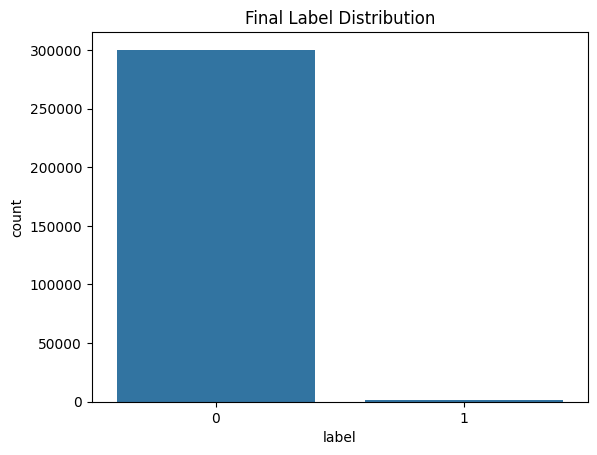

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_final)
plt.title("Final Label Distribution")
plt.show()

In [77]:
X_final
y_final

,label
0,0
1,0
2,1
3,0
4,0
...,...
301428,0
301429,0
301430,0
301431,0


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [80]:
y_pred = rf_model.predict(X_test)



In [81]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     60045
           1       0.87      0.50      0.63       242

    accuracy                           1.00     60287
   macro avg       0.93      0.75      0.82     60287
weighted avg       1.00      1.00      1.00     60287



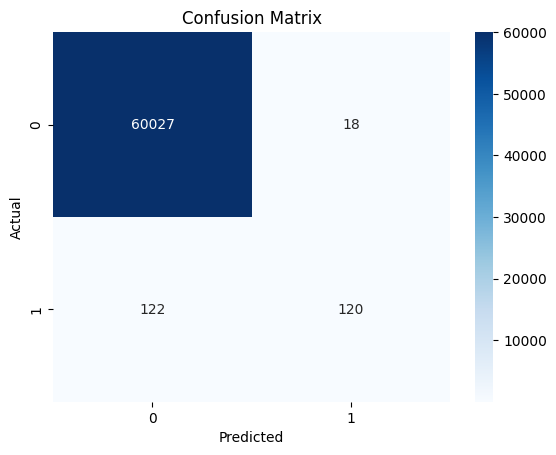

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Trying Logistic Regression

In [83]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     60045
           1       0.92      0.43      0.58       242

    accuracy                           1.00     60287
   macro avg       0.96      0.71      0.79     60287
weighted avg       1.00      1.00      1.00     60287



In [85]:
import os
os.makedirs("src/models", exist_ok=True)

In [86]:
import pickle

with open("src/models/fraud_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")

Model saved successfully!


In [87]:
with open("src/models/random_forest.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("src/models/logistic_regression.pkl", "wb") as f:
    pickle.dump(lr_model, f)

In [88]:
y_probs = rf_model.predict_proba(X_test)[:, 1]

In [89]:
import numpy as np

threshold = 0.3  # lower than 0.5
y_pred_custom = (y_probs > threshold).astype(int)

In [90]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     60045
           1       0.66      0.54      0.59       242

    accuracy                           1.00     60287
   macro avg       0.83      0.77      0.80     60287
weighted avg       1.00      1.00      1.00     60287



In [91]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [92]:
import pandas as pd

importances = rf_model.feature_importances_

feature_names = ['amount'] + [f'text_{i}' for i in range(X_final.shape[1] - 1)]

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_df.head(10)

,feature,importance
13,text_12,0.146439
89,text_88,0.094738
22,text_21,0.079148
86,text_85,0.073197
100,text_99,0.051768
75,text_74,0.047892
50,text_49,0.044087
56,text_55,0.038582
78,text_77,0.034513
62,text_61,0.031698


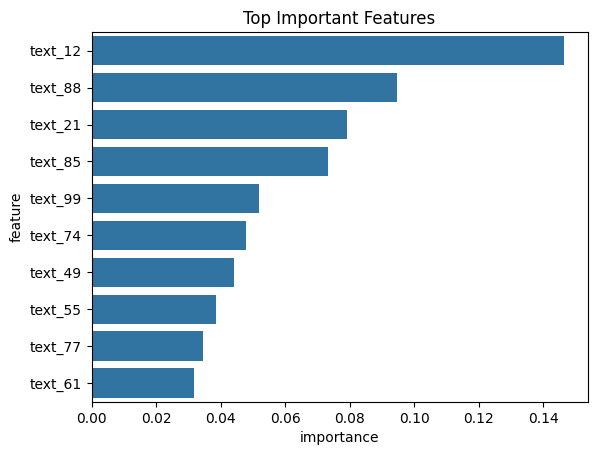

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='importance', y='feature', data=feat_df.head(10))
plt.title("Top Important Features")
plt.show()

In [94]:
!pip install shap

In [95]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test[:100])

In [97]:
import shap

explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test[:100])

In [99]:
shap_values = explainer(X_test[:100])

# FIX: select class 1
shap_values = shap_values[:, :, 1]

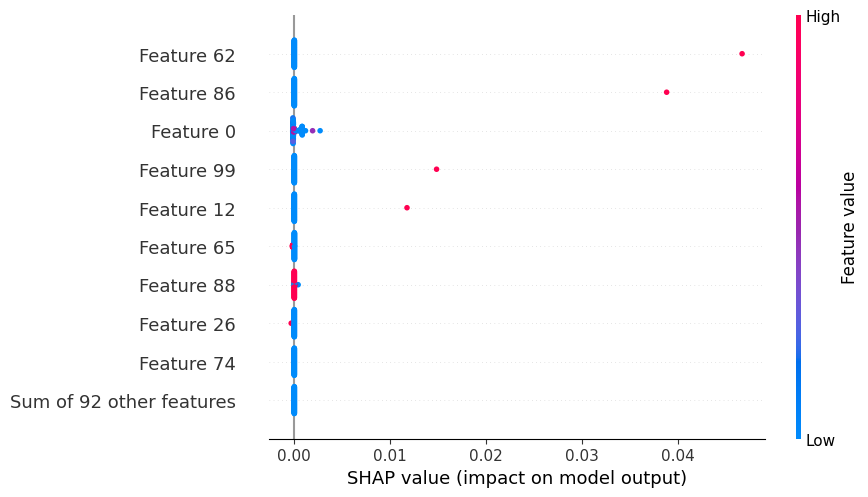

In [100]:
shap.plots.beeswarm(shap_values)

In [103]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(100, 101, 2)


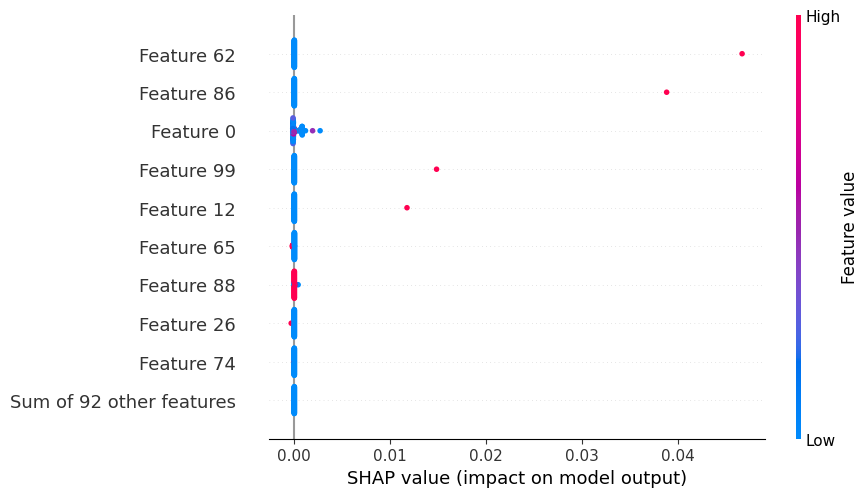

In [104]:
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test[:100])

shap_values = shap_values[:, :, 1]  # IMPORTANT

shap.plots.beeswarm(shap_values)

In [105]:
from google.colab import files
files.download("src/models/fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>